In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pomegranate.hmm import DenseHMM
from pomegranate.distributions import Normal
from statsmodels.tsa.stattools import adfuller, kpss
from utils import (log_returns, rogers_satchell_rv, rolling_realized_vol, rsi,
                   hmm_summary, plot_hmm_probs, overnight_gap, intraday_return,
                   volume_ratio, upper_shadow, lower_shadow)

In [2]:
spy = pd.read_csv('data/spy_ohlcv.csv', index_col=0, parse_dates=True, skiprows=[1, 2])
returns = log_returns(spy['Close']).rename('Close')

rv_daily = np.log(rogers_satchell_rv(spy).clip(lower=1e-8)).rename('rv_daily')
rv_5d    = np.log(rolling_realized_vol(spy, window=5).rename('rv_5d'))
rv_60d   = np.log(rolling_realized_vol(spy, window=60).rename('rv_60d'))
rsi_14   = rsi(spy['Close']).rename('RSI')

# overnight_gap and intraday_return are simple returns (~Normal, no transform needed)
gap      = overnight_gap(spy).rename('overnight_gap')
intraday = intraday_return(spy).rename('intraday_return')
# volume_ratio is right-skewed (lognormal), log-transform to Gaussianize
log_vol_ratio = np.log(volume_ratio(spy['Volume'], window=20).clip(lower=1e-8)).rename('log_volume_ratio')
# upper/lower shadow ratios are in [0,1]; use as-is (stationary, bounded — same treatment as RSI)
up_shadow   = upper_shadow(spy).rename('upper_shadow')
lo_shadow   = lower_shadow(spy).rename('lower_shadow')

In [3]:
t10y3m   = pd.read_csv('data/fred_t10y3m.csv',  index_col=0, parse_dates=True).squeeze().rename('T10Y3M')
baa10y   = pd.read_csv('data/fred_baa10y.csv',  index_col=0, parse_dates=True).squeeze().rename('BAA10Y')
vix      = pd.read_csv('data/fred_vix.csv',     index_col=0, parse_dates=True).squeeze().rename('VIX')
dgs2     = pd.read_csv('data/fred_dgs2.csv',    index_col=0, parse_dates=True).squeeze().rename('DGS2')
icsa     = pd.read_csv('data/fred_icsa.csv',    index_col=0, parse_dates=True).squeeze().rename('ICSA')

# CPI: compute YoY log-inflation, then shift index forward by 1 month + 15 days
# to approximate the actual release date (CPI for month M released ~mid M+1).
_cpi_raw = pd.read_csv('data/fred_cpi.csv', index_col=0, parse_dates=True).squeeze()
_cpi_yoy = np.log(_cpi_raw / _cpi_raw.shift(12)).rename('yoy_inflation')
_cpi_yoy.index = _cpi_yoy.index + pd.DateOffset(months=1, days=15)

# UMCSENT: final reading released end of reference month; shift +1 month to be safe.
_umcsent_raw = pd.read_csv('data/fred_umcsent.csv', index_col=0, parse_dates=True).squeeze()
_umcsent_shifted = _umcsent_raw.copy()
_umcsent_shifted.index = _umcsent_shifted.index + pd.DateOffset(months=1)
umcsent = _umcsent_shifted.rename('UMCSENT')

In [4]:
trading_days = returns.dropna().index

# reindex sparse/weekly/monthly series to trading days before concat
def to_daily(s):
    return s.reindex(trading_days, method='ffill')

data = pd.concat([
    returns, rv_daily, rv_5d, rv_60d,
    to_daily(t10y3m), to_daily(baa10y), to_daily(vix),
    to_daily(dgs2), to_daily(icsa), rsi_14,
    gap, intraday, log_vol_ratio,
    up_shadow, lo_shadow,
    to_daily(_cpi_yoy), to_daily(umcsent),
], axis=1).dropna()

print("Coverage per series:")
for col in data.columns:
    s = data[col].dropna()
    if len(s) == 0:
        print(f"  {col}: NO DATA")
    else:
        print(f"  {col}: {s.index[0].date()} → {s.index[-1].date()}  ({len(s)} rows)")

data = data[data.index >= '1994-01-01'].sort_index()

print(f"\nAligned dataset: {data.index[0].date()} → {data.index[-1].date()}  ({len(data)} rows)")
data.tail()

Coverage per series:
  Close: 1993-04-26 → 2026-05-15  (8322 rows)
  rv_daily: 1993-04-26 → 2026-05-15  (8322 rows)
  rv_5d: 1993-04-26 → 2026-05-15  (8322 rows)
  rv_60d: 1993-04-26 → 2026-05-15  (8322 rows)
  T10Y3M: 1993-04-26 → 2026-05-15  (8322 rows)
  BAA10Y: 1993-04-26 → 2026-05-15  (8322 rows)
  VIX: 1993-04-26 → 2026-05-15  (8322 rows)
  DGS2: 1993-04-26 → 2026-05-15  (8322 rows)
  ICSA: 1993-04-26 → 2026-05-15  (8322 rows)
  RSI: 1993-04-26 → 2026-05-15  (8322 rows)
  overnight_gap: 1993-04-26 → 2026-05-15  (8322 rows)
  intraday_return: 1993-04-26 → 2026-05-15  (8322 rows)
  log_volume_ratio: 1993-04-26 → 2026-05-15  (8322 rows)
  upper_shadow: 1993-04-26 → 2026-05-15  (8322 rows)
  lower_shadow: 1993-04-26 → 2026-05-15  (8322 rows)
  yoy_inflation: 1993-04-26 → 2026-05-15  (8322 rows)
  UMCSENT: 1993-04-26 → 2026-05-15  (8322 rows)

Aligned dataset: 1994-01-03 → 2026-05-15  (8147 rows)


,Close,rv_daily,rv_5d,rv_60d,T10Y3M,BAA10Y,VIX,DGS2,ICSA,RSI,overnight_gap,intraday_return,log_volume_ratio,upper_shadow,lower_shadow,yoy_inflation,UMCSENT
Price,,,,,,,,,,,,,,,,,
2026-05-11,0.002275,-5.672428,-5.658039,-5.051803,0.72,1.65,18.38,3.95,211000.0,76.137920,-0.001586,0.003870,-0.129555,0.343318,0.000000,0.032663,53.3
2026-05-12,-0.001516,-4.845070,-5.413094,-5.054994,0.76,1.66,17.99,4.00,211000.0,74.730595,-0.003260,0.001751,0.087437,0.094156,0.721825,0.032663,53.3
2026-05-13,0.005579,-4.918042,-5.258897,-5.060471,0.77,1.66,17.87,3.98,211000.0,76.458600,0.000393,0.005200,-0.102003,0.189571,0.355450,0.032663,53.3
2026-05-14,0.007863,-5.551991,-5.311731,-5.066890,0.78,1.62,17.26,4.00,211000.0,78.685755,0.001805,0.006078,-0.072481,0.227812,0.015080,0.032663,53.3
2026-05-15,-0.012102,-5.373853,-5.216333,-5.067274,0.90,1.62,17.26,4.00,211000.0,68.039222,-0.008527,-0.003532,0.223914,0.303644,0.219993,0.032663,53.3


## Stationarity — ADF and KPSS

In [5]:
def adf_summary(series: pd.Series) -> dict:
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'ADF stat':   round(result[0], 4),
        'ADF p-val':  round(result[1], 4),
        'ADF lags':   result[2],
        'ADF stat?':  result[1] < 0.05,
    }

def kpss_summary(series: pd.Series) -> dict:
    # H0 for KPSS is stationarity, so p < 0.05 means non-stationary
    result = kpss(series.dropna(), regression='c', nlags='auto')
    return {
        'KPSS stat':  round(result[0], 4),
        'KPSS p-val': round(result[1], 4),
        'KPSS stat?': result[1] >= 0.05,
    }

adf   = pd.DataFrame({col: adf_summary(data[col])  for col in data.columns}).T
kpss_ = pd.DataFrame({col: kpss_summary(data[col]) for col in data.columns}).T

pd.concat([adf, kpss_], axis=1)

C:\Users\mikah\AppData\Local\Temp\ipykernel_32528\3659217766.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\mikah\AppData\Local\Temp\ipykernel_32528\3659217766.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\mikah\AppData\Local\Temp\ipykernel_32528\3659217766.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\mikah\AppData\Local\Temp\ipykernel_32528\3659217766.py:12: InterpolationWarning: The test statist

,ADF stat,ADF p-val,ADF lags,ADF stat?,KPSS stat,KPSS p-val,KPSS stat?
Close,-16.6578,0.0,33,True,0.1326,0.1,True
rv_daily,-6.5995,0.0,37,True,0.7584,0.01,False
rv_5d,-6.2556,0.0,35,True,1.1524,0.01,False
rv_60d,-6.1843,0.0,20,True,0.9131,0.01,False
T10Y3M,-2.4546,0.1269,24,False,2.2817,0.01,False
BAA10Y,-3.4358,0.0098,33,True,1.3621,0.01,False
VIX,-6.9674,0.0,10,True,0.4235,0.067,True
DGS2,-1.5244,0.5214,29,False,6.0747,0.01,False
ICSA,-7.7594,0.0,33,True,0.1234,0.1,True
RSI,-18.8076,0.0,0,True,0.393,0.0802,True


In [6]:
def hurst(series: pd.Series) -> float:
    """Hurst exponent via R/S analysis. H>0.5 = persistence, H<0.5 = mean-reversion."""
    x = series.dropna().values
    lags = np.unique(np.floor(np.logspace(1, np.log10(len(x) // 2), 20)).astype(int))
    rs_vals = []
    for lag in lags:
        chunks = [x[i:i + lag] for i in range(0, len(x) - lag + 1, lag)]
        rs_per_chunk = []
        for chunk in chunks:
            mean_adj = chunk - chunk.mean()
            cumdev   = mean_adj.cumsum()
            rs       = (cumdev.max() - cumdev.min()) / (chunk.std(ddof=1) + 1e-12)
            rs_per_chunk.append(rs)
        rs_vals.append(np.mean(rs_per_chunk))
    # OLS fit of log(R/S) ~ H * log(lag)
    log_lags = np.log(lags)
    log_rs   = np.log(rs_vals)
    H = np.polyfit(log_lags, log_rs, 1)[0]
    return round(H, 4)

hurst_results = pd.DataFrame(
    {'Hurst exponent': {col: hurst(data[col]) for col in data.columns}}
)
hurst_results['interpretation'] = hurst_results['Hurst exponent'].apply(
    lambda h: 'persistent (long memory)' if h > 0.55 else ('mean-reverting' if h < 0.45 else 'near random walk')
)
hurst_results


,Hurst exponent,interpretation
Close,0.5469,near random walk
rv_daily,0.8982,persistent (long memory)
rv_5d,0.9238,persistent (long memory)
rv_60d,0.9492,persistent (long memory)
T10Y3M,1.0031,persistent (long memory)
BAA10Y,0.9812,persistent (long memory)
VIX,0.9523,persistent (long memory)
DGS2,1.0146,persistent (long memory)
ICSA,0.9602,persistent (long memory)
RSI,0.7990,persistent (long memory)


## Plots

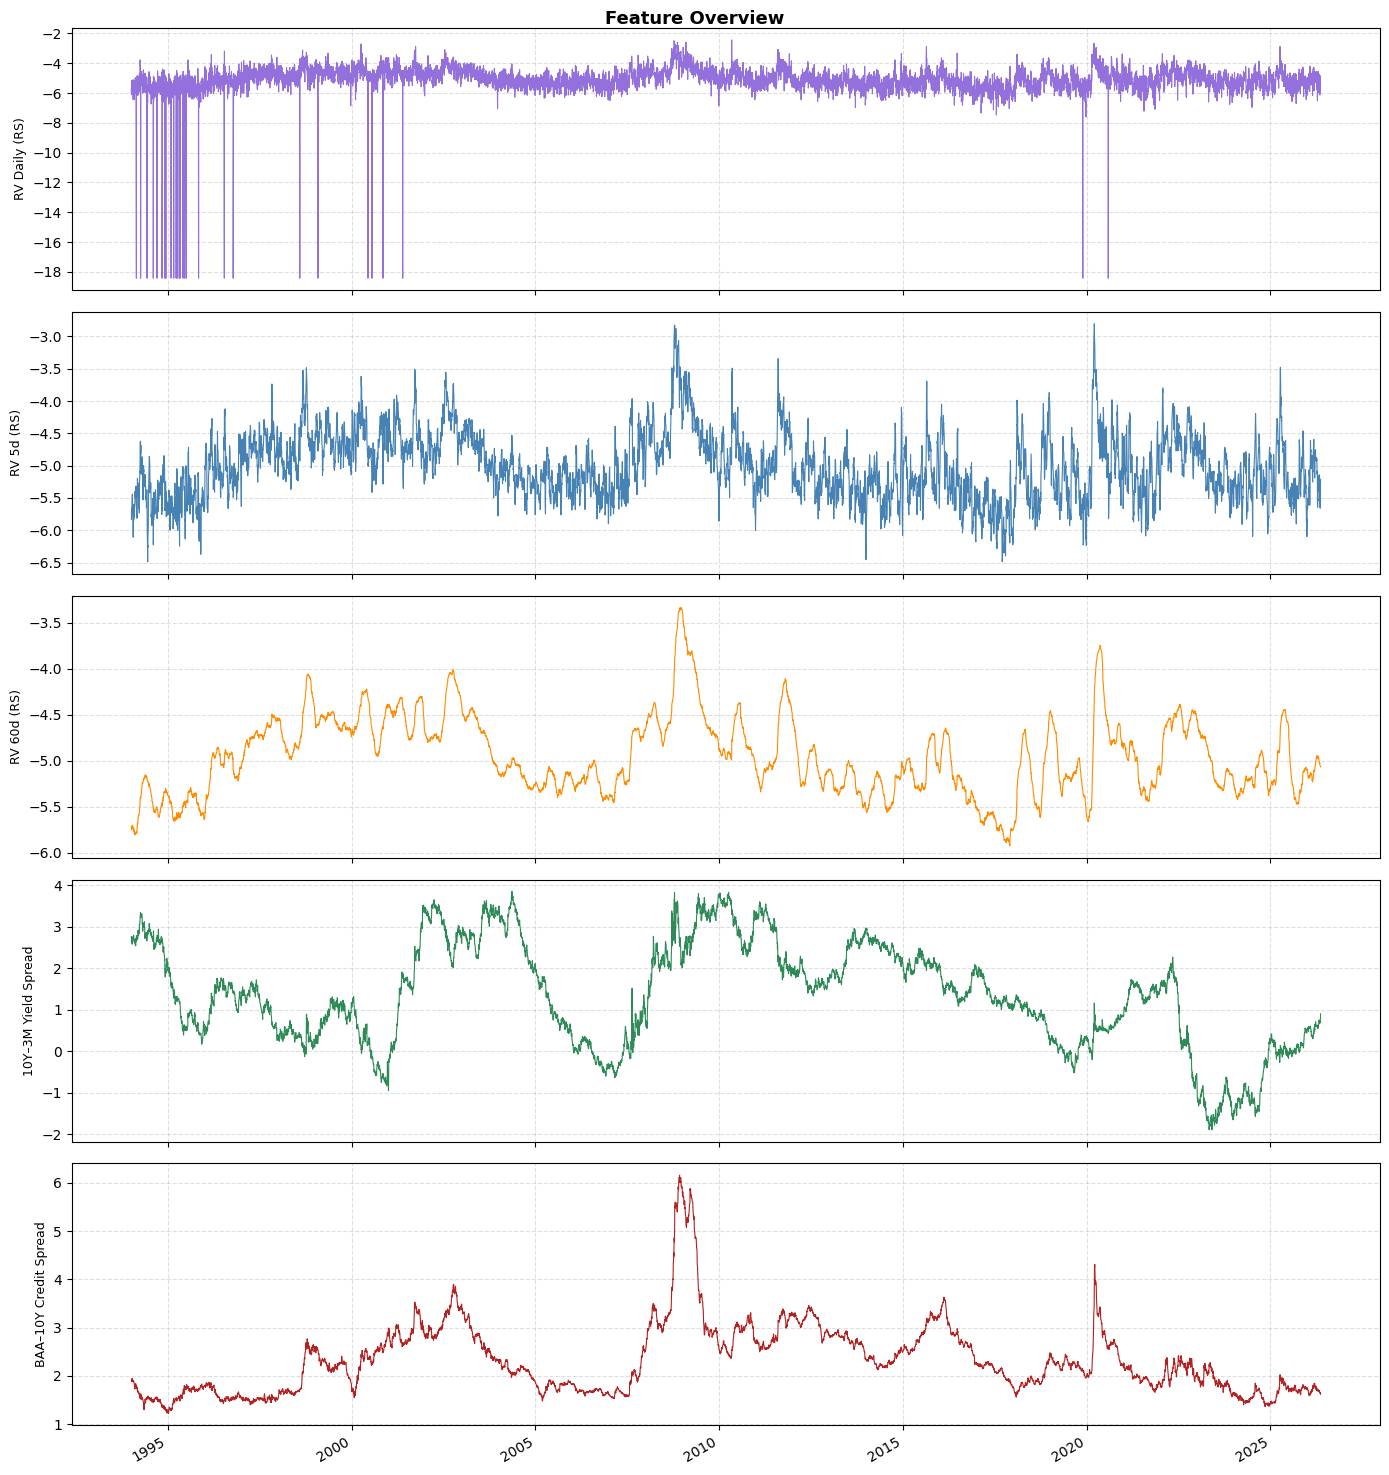

In [7]:
fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)

plot_cfg = [
    ('rv_daily', 'RV Daily (RS)',         'mediumpurple'),
    ('rv_5d',    'RV 5d (RS)',            'steelblue'),
    ('rv_60d',   'RV 60d (RS)',           'darkorange'),
    ('T10Y3M',   '10Y–3M Yield Spread',   'seagreen'),
    ('BAA10Y',   'BAA–10Y Credit Spread', 'firebrick'),
]

for ax, (col, title, color) in zip(axes, plot_cfg):
    ax.plot(data.index, data[col], color=color, linewidth=0.8)
    ax.set_ylabel(title, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Feature Overview', fontsize=13, fontweight='bold')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [8]:
data.columns

Index(['Close', 'rv_daily', 'rv_5d', 'rv_60d', 'T10Y3M', 'BAA10Y', 'VIX',
       'DGS2', 'ICSA', 'RSI', 'overnight_gap', 'intraday_return',
       'log_volume_ratio', 'upper_shadow', 'lower_shadow', 'yoy_inflation',
       'UMCSENT'],
      dtype='str')

## Model

In [20]:
from sklearn.preprocessing import StandardScaler

features = ['rv_daily', 'rv_5d', 'VIX', 'overnight_gap', 'intraday_return', 'log_volume_ratio',
            'upper_shadow', 'lower_shadow']

scaler = StandardScaler()
scaled = scaler.fit_transform(data[features].values)
X = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0)

In [21]:
model = DenseHMM(
    distributions=[Normal() for _ in range(3)],
    max_iter=1000,
    tol=1e-4,
    verbose=True
)

model.fit(X)

[1] Improvement: 2284.671875, Time: 0.8074s
[2] Improvement: 581.4765625, Time: 0.8468s
[3] Improvement: 558.0546875, Time: 0.8047s
[4] Improvement: 647.1484375, Time: 0.7996s
[5] Improvement: 809.609375, Time: 0.8254s
[6] Improvement: 1324.5703125, Time: 0.8067s
[7] Improvement: 1772.9140625, Time: 0.8298s
[8] Improvement: 1212.515625, Time: 0.7779s
[9] Improvement: 487.390625, Time: 0.8109s
[10] Improvement: 491.2578125, Time: 0.8189s
[11] Improvement: 725.71875, Time: 0.8111s
[12] Improvement: 392.4140625, Time: 0.8867s
[13] Improvement: 268.203125, Time: 0.8517s
[14] Improvement: 177.4140625, Time: 0.9002s
[15] Improvement: 101.140625, Time: 0.8241s
[16] Improvement: 44.5, Time: 0.8065s
[17] Improvement: 26.078125, Time: 0.7674s
[18] Improvement: 11.0, Time: 0.7994s
[19] Improvement: 3.9765625, Time: 0.8133s
[20] Improvement: 0.5078125, Time: 0.7985s
[21] Improvement: 28.734375, Time: 1.019s
[22] Improvement: 2.8203125, Time: 0.9397s
[23] Improvement: 10.75, Time: 0.7977s
[24] Impr

DenseHMM(
  (start): Silent()
  (end): Silent()
  (distributions): ModuleList(
    (0-2): 3 x Normal()
  )
)

In [22]:
hmm_summary(model)

Transition matrix:
tensor([[0.6423, 0.3281, 0.0296],
        [0.5634, 0.3581, 0.0775],
        [0.2348, 0.1931, 0.5721]])

State 0:
  feature 0: mean=-0.168601  std=0.533406  CV=-3.1637
  feature 1: mean=-0.314870  std=0.824480  CV=-2.6185
  feature 2: mean=-0.361029  std=0.582217  CV=-1.6127
  feature 3: mean=0.042827  std=0.631013  CV=14.7340
  feature 4: mean=0.380502  std=0.427312  CV=1.1230
  feature 5: mean=-0.188571  std=0.926965  CV=-4.9157
  feature 6: mean=0.092984  std=1.021038  CV=10.9807
  feature 7: mean=0.164518  std=1.033578  CV=6.2825

State 1:
  feature 0: mean=0.157624  std=0.516849  CV=3.2790
  feature 1: mean=0.042184  std=0.816102  CV=19.3464
  feature 2: mean=0.016310  std=0.681858  CV=41.8060
  feature 3: mean=-0.013582  std=0.737745  CV=-54.3177
  feature 4: mean=-0.702918  std=0.503629  CV=-0.7165
  feature 5: mean=0.192509  std=0.916022  CV=4.7583
  feature 6: mean=-0.068883  std=0.946780  CV=-13.7448
  feature 7: mean=-0.154747  std=0.899012  CV=-5.8096

Sta

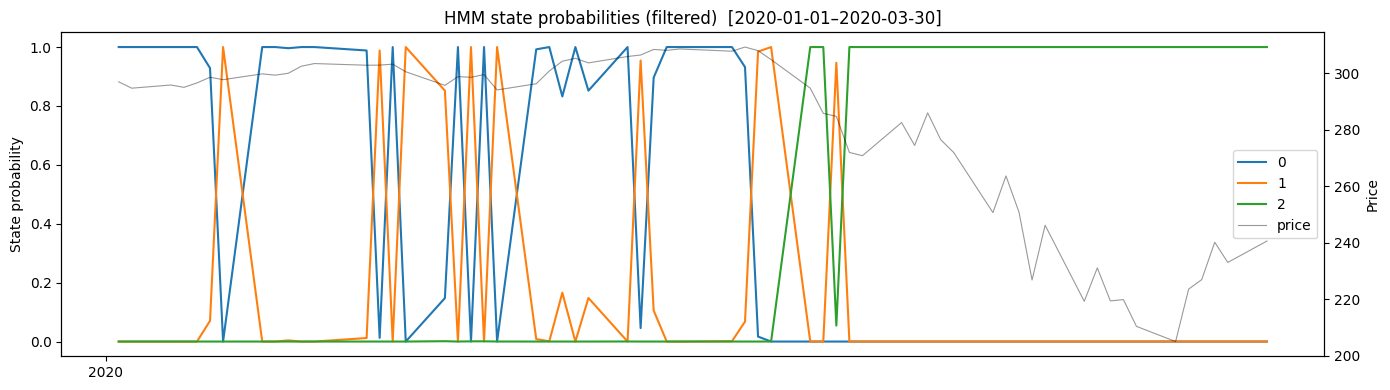

In [30]:
dates = data.index
plot_hmm_probs(model, X, dates, spy['Close'], state_labels = [0, 1, 2], start = '2020-01-01', end = '2020-03-30')